In [3]:
# import subprocess
# import sys
# package = 'curved-text'
# install_command = [sys.executable, "-m", "pip", "install", package]
# subprocess.check_call(install_command)
# # pip install matplotlib-curved-text

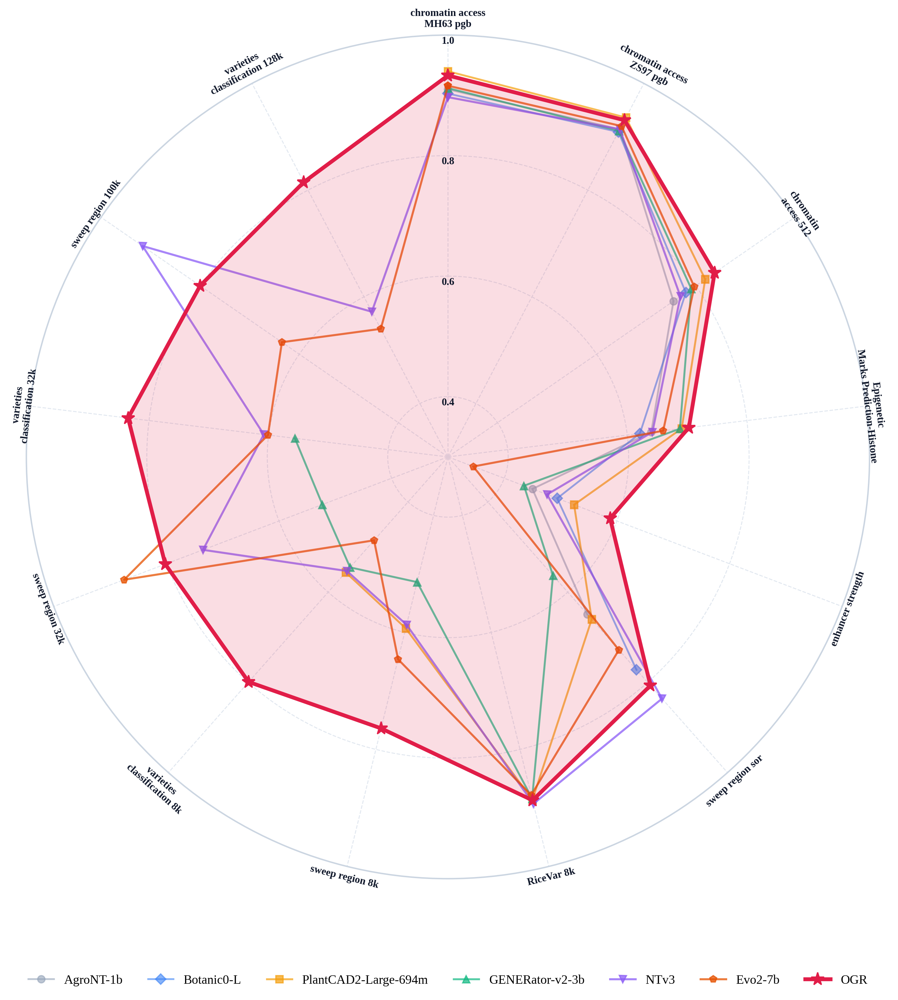

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 统一字体：Times New Roman ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学符号与 Times 风格匹配
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取并清洗数据
df = pd.read_csv('evaluation2.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']

data = df.set_index('Evaluation Dataset').copy()
for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = [
    'chromatin_access_MH63_pgb',
    'chromatin_access_ZS97_pgb',
    'chromatin_access_512',
    'Epigenetic_Marks_Prediction-Histone',
    'enhancer_strength',
    'sweep_region_sor',
    'RiceVar_8k',
    'sweep_region_8k',
    'varieties_classification_8k',
    'sweep_region_32k',
    'varieties_classification_32k',
    'sweep_region_100k',
    'varieties_classification_128k'
]

data_reordered = data.loc[ordered_datasets]

N = len(ordered_datasets)
# angles 包含全部 13 个数据集对应的角度
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(11.5, 11.5), dpi=300)
ax = fig.add_subplot(111, polar=True)

# 12点钟方向起点，顺时针
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 【关键修正】：使用 angles 替代 angles[:-1]，确保绘制全部 13 条雷达轴
ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0.3, 1.0)

ax.grid(color='#E2E8F0', linestyle='--', linewidth=0.8)
ax.spines['polar'].set_color('#CBD5E1')
ax.spines['polar'].set_linewidth(1.2)

# 样式映射
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': '#E11D48', 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

# 绘制折线
for model in models:
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        linestyle='-',
        marker=style['marker'],
        markersize=style.get('ms', 6),
        label=model,
        alpha=style['alpha'],
        zorder=style['zorder']
    )
    
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.15, zorder=style['zorder']-1)

import matplotlib.patheffects as path_effects  # 需在代码顶部 import

# 2. 刻度控制：正上方中轴线（angles[0]）且处于圆圈内侧
center_angle = angles[0]
for tick_val in [0.4, 0.6, 0.8, 1.0]:
    r_val = tick_val - 0.01 if tick_val == 1.0 else tick_val - 0.01
    
    txt = ax.text(
        center_angle, r_val, f"{tick_val:.1f}",
        fontsize=8.5,
        fontweight='bold',
        color='#0F172A',
        ha='center',
        va='center',
        zorder=30
    )
    # # 给文字加一层 2px 的白色文字描边，代替实心背景框
    # txt.set_path_effects([
    #     path_effects.withStroke(linewidth=2.5, foreground='white', alpha=0.8)
    # ])

# 3. 外侧数据集标签（精简版）
r_pos = 1.01

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    # 处理名字与长文本自动换行
    words = dataset.replace('_', ' ').split(' ')
    mid = len(words) // 2
    clean_name = f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}" if len(' '.join(words)) > 18 and mid > 0 else ' '.join(words)
    
    # 动态确定垂直对齐方式
    va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    
    ax.text(
        angle_rad, r_pos, clean_name,
        rotation=rot, rotation_mode='anchor',
        ha='center', va=va,
        fontsize=8.5, fontweight='bold', color='#0F172A', multialignment='center'
    )

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=7,
    frameon=False,        # 关闭边框
    fontsize=10.5,
    # title='Models',
    title_fontsize=11.5
)

plt.tight_layout()
plt.savefig('radar_scale_inside_perfect.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3990751/1455261846.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


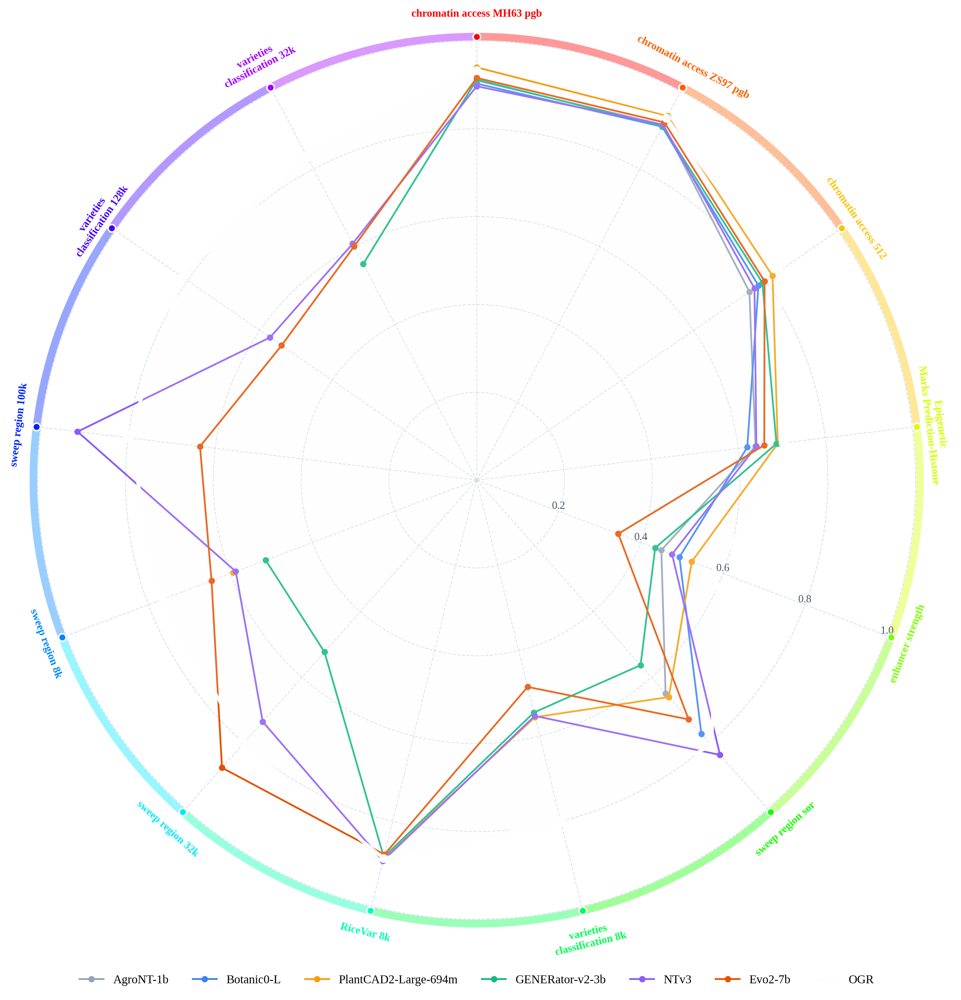

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 统一字体：Times New Roman ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学符号与 Times 风格匹配
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('evaluation2.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']
data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = [
    'chromatin_access_MH63_pgb',
    'chromatin_access_ZS97_pgb',
    'chromatin_access_512',
    'Epigenetic_Marks_Prediction-Histone',
    'enhancer_strength',
    'sweep_region_sor',
    'varieties_classification_8k',
    'RiceVar_8k',
    'sweep_region_32k',
    'sweep_region_8k',
    'sweep_region_100k',
    'varieties_classification_128k',
    'varieties_classification_32k'
]

data_reordered = data.loc[ordered_datasets]

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.01  # 色环半径

# ---------------------------------------------------------
# 💡 优化 1：生成顶刊级别的柔和连续渐变色系 (HSL / Spectral)
# ---------------------------------------------------------
# 使用 HSV 空间平滑映射 13 个数据点的渐变色，保证颜色环连贯自然
cmap = plt.cm.get_cmap('hsv')
colors = [cmap(i / float(N) * 0.85) for i in range(N)]  # 取 0.85 避免首尾红红重叠

# ---------------------------------------------------------
# 2. 画布与基础设置
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
ax = fig.add_subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.7)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 💡 优化 2：绘制外围圆弧与高质感白边圆点
# ---------------------------------------------------------


for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1: 
        a2 += 2 * np.pi
    
    # 画半透明渐变圆弧
    arc_theta = np.linspace(a1, a2, 40)
    arc_r = np.full_like(arc_theta, ring_r)
    ax.plot(arc_theta, arc_r, color=colors[i], linewidth=6, alpha=0.4, solid_capstyle='round')
    
    # 绘制高质感节点小圆点（带有白色描边，层次感极强）
    ax.scatter(angles[i], ring_r, color=colors[i], s=35, edgecolor='white', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.4, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 'o', 'lw': 1.4, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': 'o', 'lw': 1.4, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'o', 'lw': 1.4, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'o', 'lw': 1.4, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'o', 'lw': 1.4, 'zorder': 6},
    'OGR': {'color': '#E11D48', 'marker': 'o', 'lw': 2.6, 'ms': 6, 'zorder': 10}
}

# # 样式映射
# model_styles = {
#     'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
#     'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 'o', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
#     'GENERator-v2-3b': {'color': '#10B981', 'marker': 'o', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
#     'Botanic0-L': {'color': '#3B82F6', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
#     'NTv3': {'color': '#8B5CF6', 'marker': 'o', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
#     'Evo2-7b': {'color': '#E65100', 'marker': 'o', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
#     'OGR': {'color': '#E11D48', 'marker': 'o', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
# }

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.15, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='#475569',
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 💡 优化 3：智能分行 + 经典切线旋转标签（解决字间距错乱问题）
# ---------------------------------------------------------
r_text = ring_r + 0.04  # 标签半径

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    # 处理名字与长文本自动换行
    words = dataset.replace('_', ' ').split(' ')
    mid = len(words) // 2
    clean_name = f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}" if len(' '.join(words)) > 25 and mid > 0 else ' '.join(words)
    
    # 动态确定垂直对齐方式
    va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    
    ax.text(
            angle_rad, r_text, clean_name,
            rotation=rot,
            rotation_mode='anchor',
            ha='center',
            va=va,
            fontsize=8.5,
            fontweight='bold',
            color=colors[i],      # 与渐变色环 100% 同色绑定
            multialignment='center',
            zorder=20
        )

# ---------------------------------------------------------
# 5. 图例排版
# ---------------------------------------------------------
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=7,
    frameon=False,
    fontsize=9.5
)

plt.tight_layout()
plt.savefig('perfect_radar.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3990751/1781931646.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


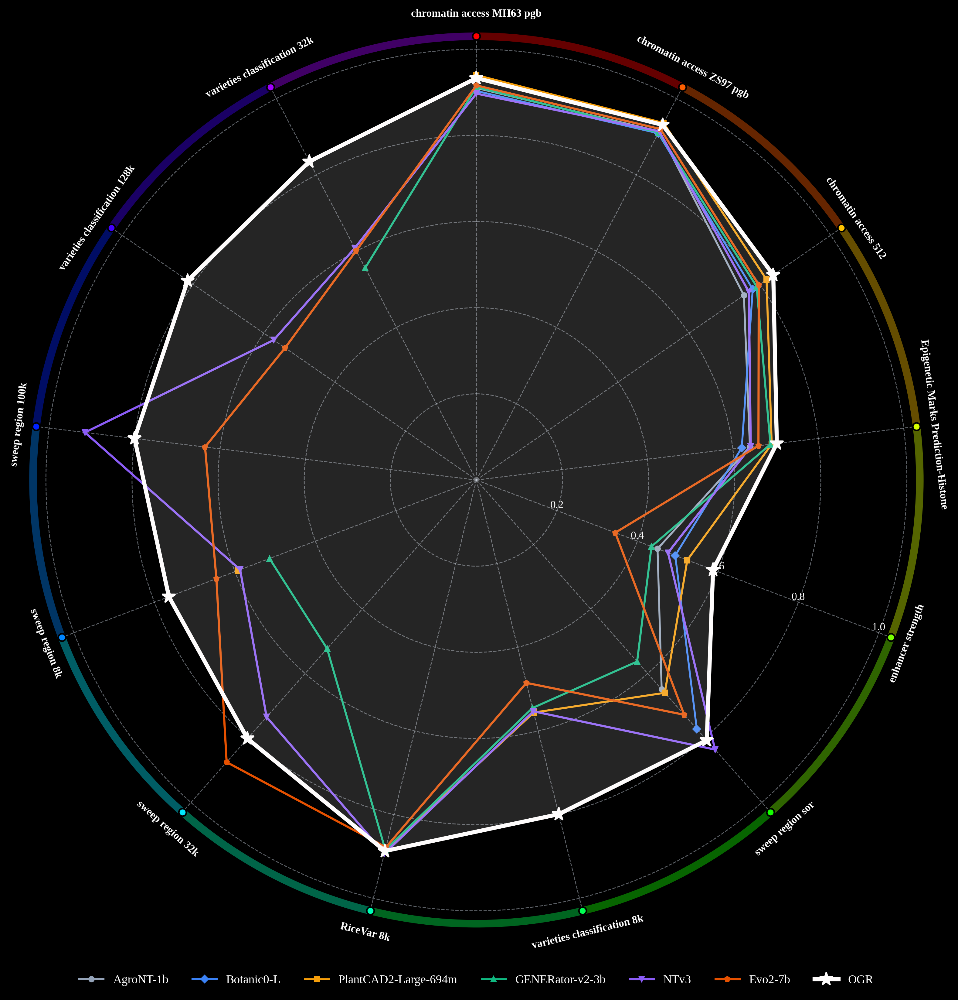

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 统一字体：Times New Roman ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学符号与 Times 风格匹配
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('evaluation2.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']
data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = [
    'chromatin_access_MH63_pgb',
    'chromatin_access_ZS97_pgb',
    'chromatin_access_512',
    'Epigenetic_Marks_Prediction-Histone',
    'enhancer_strength',
    'sweep_region_sor',
    'varieties_classification_8k',
    'RiceVar_8k',
    'sweep_region_32k',
    'sweep_region_8k',
    'sweep_region_100k',
    'varieties_classification_128k',
    'varieties_classification_32k'
]

data_reordered = data.loc[ordered_datasets]

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.03  # 色环半径

# ---------------------------------------------------------
# 💡 优化 1：生成顶刊级别的柔和连续渐变色系 (HSL / Spectral)
# ---------------------------------------------------------
# 使用 HSV 空间平滑映射 13 个数据点的渐变色，保证颜色环连贯自然
cmap = plt.cm.get_cmap('hsv')
colors = [cmap(i / float(N) * 0.85) for i in range(N)]  # 取 0.85 避免首尾红红重叠

# ---------------------------------------------------------
# 2. 画布与基础设置（黑底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('black')          # 画布黑底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('black')                 # 坐标区黑底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，黑底上提亮保证可见）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.45)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 💡 优化 2：绘制外围圆弧与高质感圆点
# ---------------------------------------------------------

for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1: 
        a2 += 2 * np.pi
    
    # 画半透明渐变圆弧（黑底上略微提亮）
    arc_theta = np.linspace(a1, a2, 40)
    arc_r = np.full_like(arc_theta, ring_r)
    ax.plot(arc_theta, arc_r, color=colors[i], linewidth=6, alpha=0.4, solid_capstyle='round')
    
    # 绘制高质感节点小圆点（黑色描边与黑底融合，干净利落）
    ax.scatter(angles[i], ring_r, color=colors[i], s=35, edgecolor='black', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#FEFCFC", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.15, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='white',   # 白字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 💡 优化 3：智能分行 + 经典切线旋转标签（解决字间距错乱问题）
# ---------------------------------------------------------
r_text = ring_r + 0.04  # 标签半径

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    # 处理名字与长文本自动换行
    words = dataset.replace('_', ' ').split(' ')
    mid = len(words) // 2
    clean_name = f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}" if len(' '.join(words)) > 60 and mid > 0 else ' '.join(words)
    
    # 动态确定垂直对齐方式
    va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    
    ax.text(
            angle_rad, r_text, clean_name,
            rotation=rot,
            rotation_mode='anchor',
            ha='center',
            va=va,
            fontsize=8.5,
            fontweight='bold',
            color='white',   # 白字
            multialignment='center',
            zorder=20
        )

# ---------------------------------------------------------
# 5. 图例排版（黑底白字）
# ---------------------------------------------------------
leg = plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
for text in leg.get_texts():
    text.set_color('white')   # 图例文字改白

plt.tight_layout()
plt.savefig('perfect_radar_black.png', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

In [ ]:
data_reordered.index

Index(['chromatin_access_MH63_pgb', 'chromatin_access_ZS97_pgb',
       'poly_a_japonica_pgb', 'poly_a_indica_agront', 'bulk_gene_exp_pgb',
       'chromatin_access_512', 'Epigenetic_Marks_Prediction-Histone',
       'smallRNA', 'splice_sites_labels', 'RiceVar_512', 'enhancer_strength',
       'enhancer_regions', 'lncRNA', 'rice_nlr', 'RiceVar_6k',
       'CDS_multilabel', 'bulk_single_base_Callus', 'sweep_region_psr',
       'sweep_region_sor', 'RiceVar_8k', 'varieties_classification_8k',
       'sweep_region_8k', 'sweep_region_32k', 'varieties_classification_32k',
       'sweep_region_100k', 'varieties_classification_128k',
       'varieties_classification_1m'],
      dtype='object', name='Evaluation Dataset')

/tmp/ipykernel_3990751/2664496130.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


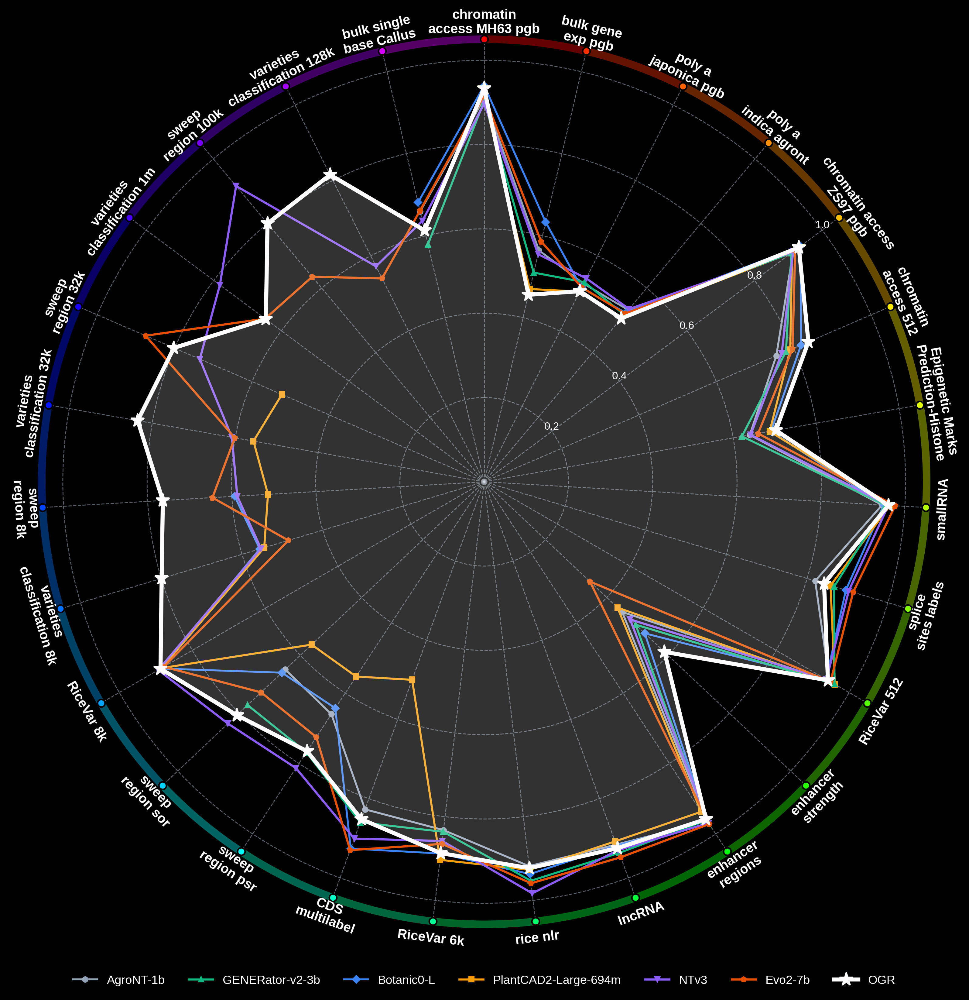

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 统一字体：Arial ----
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'    # 数学符号与无衬线风格匹配
plt.rcParams['axes.unicode_minus'] = False
# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('evaluation3.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']
data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = ['chromatin_access_MH63_pgb', 'bulk_gene_exp_pgb',
       'poly_a_japonica_pgb', 'poly_a_indica_agront', 'chromatin_access_ZS97_pgb',
       'chromatin_access_512', 'Epigenetic_Marks_Prediction-Histone',
       'smallRNA', 'splice_sites_labels', 'RiceVar_512', 'enhancer_strength',
       'enhancer_regions', 'lncRNA', 'rice_nlr', 'RiceVar_6k',
       'CDS_multilabel', 'sweep_region_psr',
       'sweep_region_sor', 'RiceVar_8k', 'varieties_classification_8k',
       'sweep_region_8k', 'varieties_classification_32k', 'sweep_region_32k',
       'varieties_classification_1m', 'sweep_region_100k', 'varieties_classification_128k',
       'bulk_single_base_Callus']

data_reordered = data.loc[ordered_datasets]
# data_reordered = data.copy()

# 💡 动态设置：根据数据行数自动生成数据集顺序（有多少行就画多少条雷达轴）
ordered_datasets = data_reordered.index.tolist()

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.05  # 色环半径

# ---------------------------------------------------------
# 💡 优化 1：生成顶刊级别的柔和连续渐变色系 (HSL / Spectral)
# ---------------------------------------------------------
# 使用 HSV 空间平滑映射 N 个数据点的渐变色，保证颜色环连贯自然
cmap = plt.cm.get_cmap('hsv')
colors = [cmap(i / float(N) * 0.85) for i in range(N)]  # 取 0.85 避免首尾红红重叠

# ---------------------------------------------------------
# 2. 画布与基础设置（黑底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('black')          # 画布黑底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('black')                 # 坐标区黑底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，黑底上提亮保证可见）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.45)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 💡 优化 2：绘制外围圆弧与高质感圆点
# ---------------------------------------------------------

for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1: 
        a2 += 2 * np.pi
    
    # 画半透明渐变圆弧（黑底上略微提亮）
    arc_theta = np.linspace(a1, a2, 40)
    arc_r = np.full_like(arc_theta, ring_r)
    ax.plot(arc_theta, arc_r, color=colors[i], linewidth=6, alpha=0.4, solid_capstyle='round')
    
    # 绘制高质感节点小圆点（黑色描边与黑底融合，干净利落）
    ax.scatter(angles[i], ring_r, color=colors[i], s=35, edgecolor='black', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#FEFCFC", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.2, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='white',   # 白字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 💡 优化 3：智能分行 + 经典切线旋转标签（解决字间距错乱问题）
# ---------------------------------------------------------
r_text = ring_r + 0.04  # 标签半径

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    manual_split = {
    'Epigenetic_Marks_Prediction-Histone': 'Epigenetic Marks\nPrediction-Histone',
    'chromatin_access_MH63_pgb':       'chromatin\naccess MH63 pgb',
    }

    if dataset in manual_split:
        clean_name = manual_split[dataset]
    else:
        words = dataset.replace('_', ' ').split(' ')
        mid = len(words) // 2
        clean_name = (
            f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}"
            if len(' '.join(words)) > 12 and mid > 0
            else ' '.join(words)
        )
    
    # 动态确定垂直对齐方式
    # va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    va = 'center' if 45 <= screen_angle <= 135 else ('center' if 225 <= screen_angle <= 315 else 'center')
    ax.text(
            angle_rad, r_text, clean_name,
            rotation=rot,
            rotation_mode='anchor',
            ha='center',
            va=va,
            fontsize=10.5,
            fontweight='bold',
            color='white',   # 白字
            multialignment='center',
            zorder=20
        )

# ---------------------------------------------------------
# 5. 图例排版（黑底白字）
# ---------------------------------------------------------
leg = plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
for text in leg.get_texts():
    text.set_color('white')   # 图例文字改白

plt.tight_layout()
# plt.savefig('perfect_radar_black.png', dpi=300, bbox_inches='tight', facecolor='black')
plt.savefig('perfect_radar_black_0.2.pdf', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

/tmp/ipykernel_677946/4191037793.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


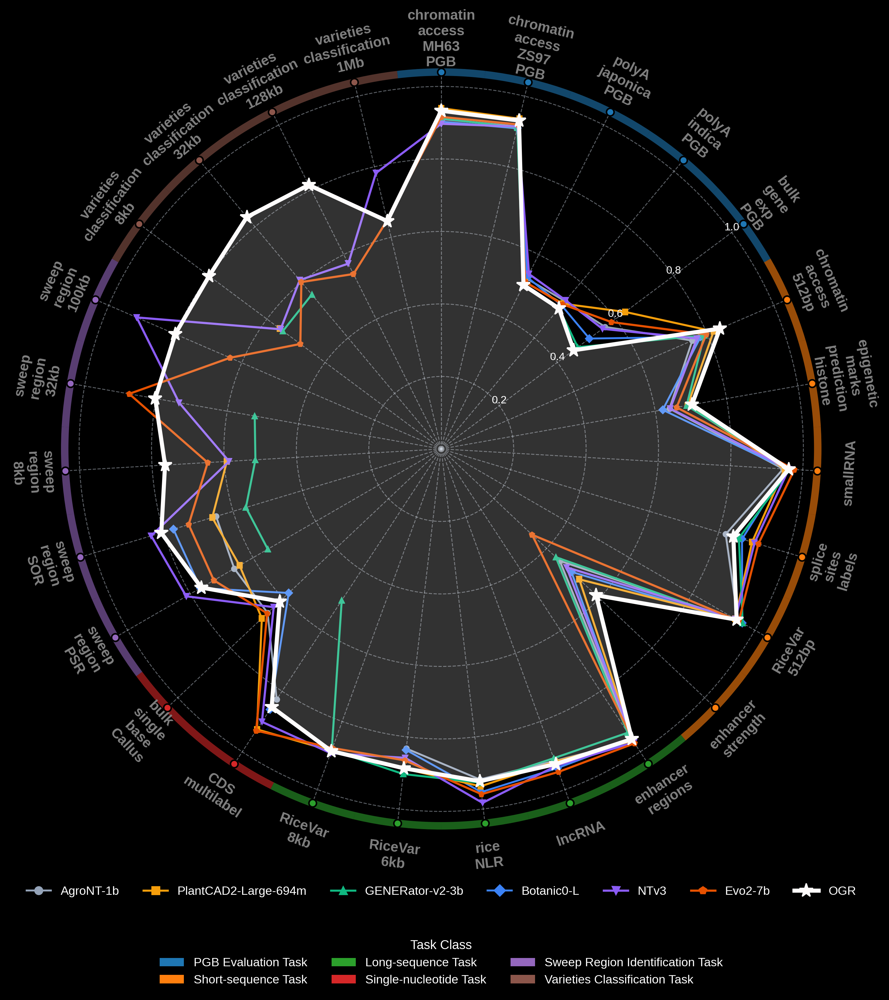

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ---- 统一字体：Arial ----
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'    # 数学符号与无衬线风格匹配
plt.rcParams['axes.unicode_minus'] = False
# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('OGR_radar.csv')

# class 列：数据集 → 类别映射（用于外圈色环配色与图例）
class_map = dict(zip(df['Evaluation Dataset'], df['class']))
models = [c for c in df.columns if c not in ('Evaluation Dataset', 'class')]

data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

data_reordered = data.copy()

# 动态设置：根据数据行数自动生成数据集顺序（有多少行就画多少条雷达轴）
ordered_datasets = data_reordered.index.tolist()

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.04  # 色环半径

# ---------------------------------------------------------
# 优化 1：外圈色环颜色与数据集的 class 类别一一对应
#    同一类别的数据集使用同一颜色（tab10 调色板）
# ---------------------------------------------------------
unique_classes = list(dict.fromkeys(class_map.values()))                     # 按出现顺序去重
cmap = plt.cm.get_cmap('tab10')
class_to_color = {c: cmap(i % 10) for i, c in enumerate(unique_classes)}     # 类别 → 颜色
colors = [class_to_color[class_map[d]] for d in ordered_datasets]            # 每条轴线取对应类别颜色

# ---------------------------------------------------------
# 2. 画布与基础设置（黑底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('black')          # 画布黑底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('black')                 # 坐标区黑底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，黑底上提亮保证可见）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.45)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 优化 2：外围圆弧与节点，颜色 = 数据集类别颜色
# ---------------------------------------------------------

# 色环为无缝环带：相邻两个点之间的区域由两种颜色各占一半——
# 前半段（本节点→中点）用左侧节点的类别颜色，
# 后半段（中点→下一节点）用右侧节点的类别颜色；
# 同一类别（同色）连续时整段颜色自然连成一片，
# 不同类别的交界处恰好在中点平分，无需任何分隔符号。
for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1:
        a2 += 2 * np.pi
    a_mid = a1 + (a2 - a1) / 2   # 两节点中点：颜色平分线

    # 前半段：本节点 → 中点，用本节点（左）颜色
    arc_theta = np.linspace(a1, a_mid, 20)
    ax.plot(arc_theta, np.full_like(arc_theta, ring_r),
            color=colors[i], linewidth=6, alpha=0.6, solid_capstyle='butt')

    # 后半段：中点 → 下一节点，用下一节点（右）颜色
    arc_theta = np.linspace(a_mid, a2, 20)
    ax.plot(arc_theta, np.full_like(arc_theta, ring_r),
            color=colors[(i + 1) % N], linewidth=6, alpha=0.6, solid_capstyle='butt')

    # 绘制高质感节点小圆点（黑色描边与黑底融合，位于色弧交界处）
    ax.scatter(a1, ring_r, color=colors[i], s=35, edgecolor='black', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#FEFCFC", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]

    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)

    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.2, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='white',   # 白字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 优化 3：数据集标签 —— 水平平行展示（不换行、不旋转）
# ---------------------------------------------------------
r_text = ring_r + 0.09  # 标签半径

import re

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    # 恢复之前的切线旋转角度（确保文字方向朝上易读）
    angle_deg = np.degrees(angle_rad)
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180

    # 按 _ 或 - 切分，每个单词单独一行
    parts = re.split(r'[_-]', dataset)      # 按 _ 或 - 切分
    clean_name = '\n'.join(parts)          # 每个部分单独一行

    ax.text(
        angle_rad, r_text, clean_name,
        rotation=rot,                       # 切线旋转角度
        rotation_mode='anchor',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='grey',
        multialignment='center',
        zorder=20
    )

# ---------------------------------------------------------
# 5. 图例排版（黑底白字）：上排 = 模型折线，下排 = 类别色环
# ---------------------------------------------------------
model_lines = [
    plt.Line2D([0], [0], color=s['color'], marker=s['marker'], lw=s['lw'],
               label=model, markerfacecolor=s['color'], markersize=s.get('ms', 6))
    for model, s in model_styles.items()
]
leg1 = ax.legend(
    handles=model_lines,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
ax.add_artist(leg1)
for t in leg1.get_texts():
    t.set_color('white')   # 图例文字改白

class_patches = [
    Patch(facecolor=class_to_color[c], edgecolor='none', label=c)
    for c in unique_classes
]
leg2 = ax.legend(
    handles=class_patches,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.13),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    title='Task Class'
)
for t in leg2.get_texts():
    t.set_color('white')   # 图例文字改白
leg2.get_title().set_color('white')

plt.tight_layout()
plt.savefig('perfect_radar_black_2_0.2.pdf', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

/tmp/ipykernel_1928354/2733849184.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


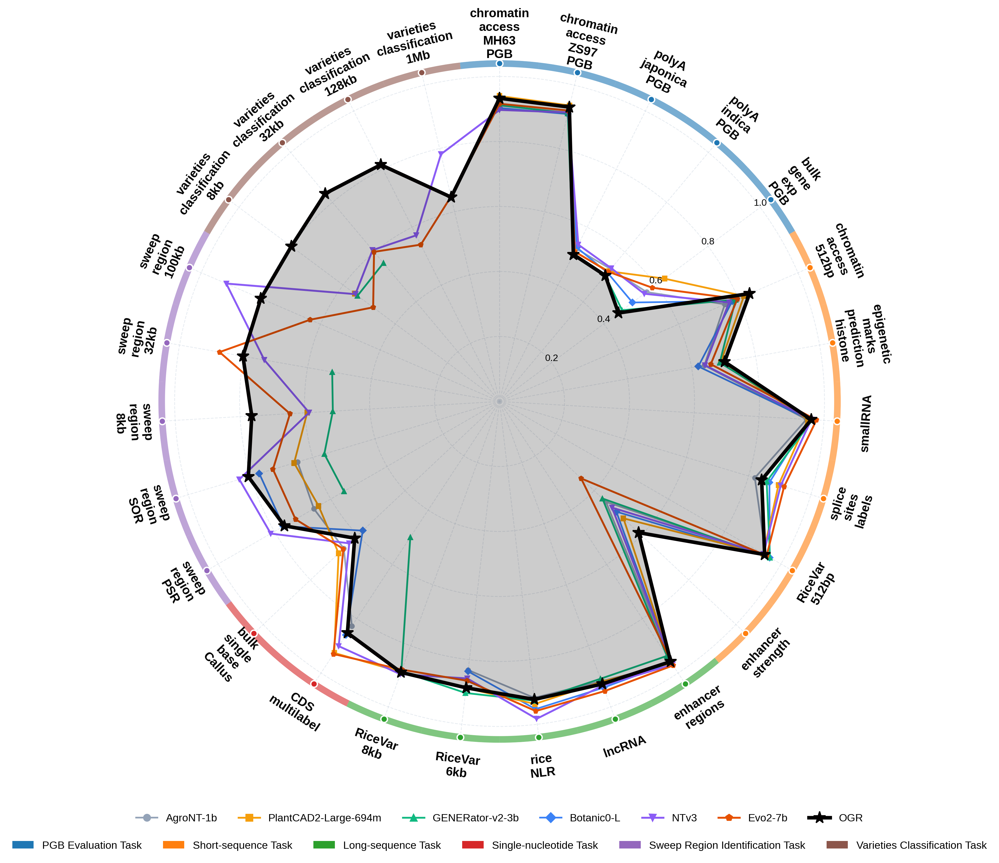

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ---- 统一字体：Arial ----
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'    # 数学符号与无衬线风格匹配
plt.rcParams['axes.unicode_minus'] = False
# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('OGR_radar.csv')

# class 列：数据集 → 类别映射（用于外圈色环配色与图例）
class_map = dict(zip(df['Evaluation Dataset'], df['class']))
models = [c for c in df.columns if c not in ('Evaluation Dataset', 'class')]

data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

data_reordered = data.copy()

# 动态设置：根据数据行数自动生成数据集顺序（有多少行就画多少条雷达轴）
ordered_datasets = data_reordered.index.tolist()

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.04  # 色环半径

# ---------------------------------------------------------
# 优化 1：外圈色环颜色与数据集的 class 类别一一对应
#    同一类别的数据集使用同一颜色（tab10 调色板）
# ---------------------------------------------------------
unique_classes = list(dict.fromkeys(class_map.values()))                     # 按出现顺序去重
cmap = plt.cm.get_cmap('tab10')
class_to_color = {c: cmap(i % 10) for i, c in enumerate(unique_classes)}     # 类别 → 颜色
colors = [class_to_color[class_map[d]] for d in ordered_datasets]            # 每条轴线取对应类别颜色

# ---------------------------------------------------------
# 2. 画布与基础设置（黑底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('white')          # 画布黑底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('white')                 # 坐标区黑底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，黑底上提亮保证可见）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.45)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 优化 2：外围圆弧与节点，颜色 = 数据集类别颜色
# ---------------------------------------------------------

# 色环为无缝环带：相邻两个点之间的区域由两种颜色各占一半——
# 前半段（本节点→中点）用左侧节点的类别颜色，
# 后半段（中点→下一节点）用右侧节点的类别颜色；
# 同一类别（同色）连续时整段颜色自然连成一片，
# 不同类别的交界处恰好在中点平分，无需任何分隔符号。
for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1:
        a2 += 2 * np.pi
    a_mid = a1 + (a2 - a1) / 2   # 两节点中点：颜色平分线

    # 前半段：本节点 → 中点，用本节点（左）颜色
    arc_theta = np.linspace(a1, a_mid, 20)
    ax.plot(arc_theta, np.full_like(arc_theta, ring_r),
            color=colors[i], linewidth=6, alpha=0.6, solid_capstyle='butt')

    # 后半段：中点 → 下一节点，用下一节点（右）颜色
    arc_theta = np.linspace(a_mid, a2, 20)
    ax.plot(arc_theta, np.full_like(arc_theta, ring_r),
            color=colors[(i + 1) % N], linewidth=6, alpha=0.6, solid_capstyle='butt')

    # 绘制高质感节点小圆点（黑色描边与黑底融合，位于色弧交界处）
    ax.scatter(a1, ring_r, color=colors[i], s=35, edgecolor='white', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#F59E0B', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#10B981', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#3B82F6', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#030000", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]

    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)

    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.2, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='black',   # 白字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 优化 3：数据集标签 —— 水平平行展示（不换行、不旋转）
# ---------------------------------------------------------
r_text = ring_r + 0.09  # 标签半径

import re

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    # 恢复之前的切线旋转角度（确保文字方向朝上易读）
    angle_deg = np.degrees(angle_rad)
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180

    # 按 _ 或 - 切分，每个单词单独一行
    parts = re.split(r'[_-]', dataset)      # 按 _ 或 - 切分
    clean_name = '\n'.join(parts)          # 每个部分单独一行

    ax.text(
        angle_rad, r_text, clean_name,
        rotation=rot,                       # 切线旋转角度
        rotation_mode='anchor',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='black',
        multialignment='center',
        zorder=20
    )

# ---------------------------------------------------------
# 5. 图例排版（黑底白字）：上排 = 模型折线，下排 = 类别色环
# ---------------------------------------------------------
model_lines = [
    plt.Line2D([0], [0], color=s['color'], marker=s['marker'], lw=s['lw'],
               label=model, markerfacecolor=s['color'], markersize=s.get('ms', 6))
    for model, s in model_styles.items()
]
leg1 = ax.legend(
    handles=model_lines,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.09),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
ax.add_artist(leg1)
for t in leg1.get_texts():
    t.set_color('black')   # 图例文字改白

class_patches = [
    Patch(facecolor=class_to_color[c], edgecolor='none', label=c)
    for c in unique_classes
]
leg2 = ax.legend(
    handles=class_patches,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.13),
    ncol=6,
    frameon=False,
    fontsize=9.5,
    # title='Task Class'
)
for t in leg2.get_texts():
    t.set_color('black')   # 图例文字改白
leg2.get_title().set_color('black')

# plt.tight_layout()
# plt.savefig('perfect_radar_black_2_0.2.pdf', dpi=300, bbox_inches='tight', facecolor='black')
# plt.show()

/tmp/ipykernel_3990751/8130996.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


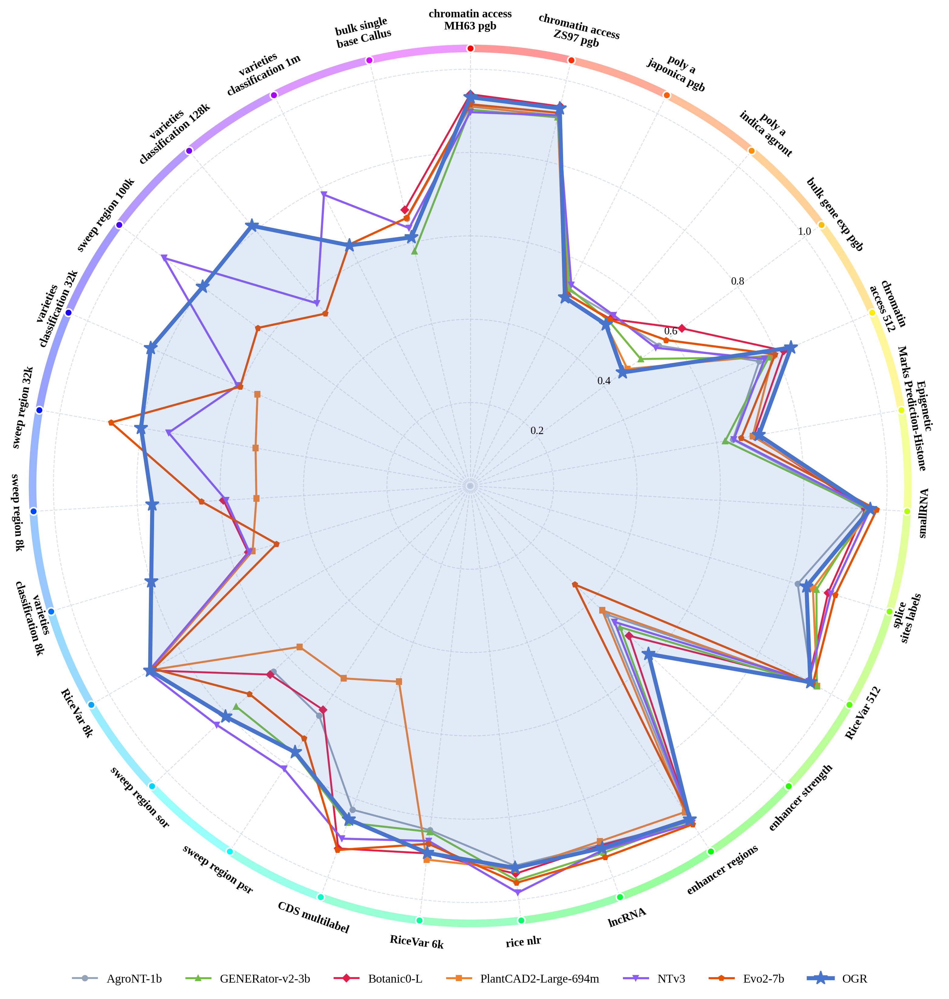

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 统一字体：Times New Roman ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学符号与 Times 风格匹配
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('evaluation3.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']
data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = ['chromatin_access_MH63_pgb', 'chromatin_access_ZS97_pgb',
       'poly_a_japonica_pgb', 'poly_a_indica_agront', 'bulk_gene_exp_pgb',
       'chromatin_access_512', 'Epigenetic_Marks_Prediction-Histone',
       'smallRNA', 'splice_sites_labels', 'RiceVar_512', 'enhancer_strength',
       'enhancer_regions', 'lncRNA', 'rice_nlr', 'RiceVar_6k',
       'CDS_multilabel', 'sweep_region_psr',
       'sweep_region_sor', 'RiceVar_8k', 'varieties_classification_8k',
       'sweep_region_8k', 'sweep_region_32k', 'varieties_classification_32k',
       'sweep_region_100k', 'varieties_classification_128k',
       'varieties_classification_1m', 'bulk_single_base_Callus']

data_reordered = data.loc[ordered_datasets]
# data_reordered = data.copy()

# 💡 动态设置：根据数据行数自动生成数据集顺序（有多少行就画多少条雷达轴）
ordered_datasets = data_reordered.index.tolist()

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.05  # 色环半径

# ---------------------------------------------------------
# 💡 优化 1：生成顶刊级别的柔和连续渐变色系 (HSL / Spectral)
# ---------------------------------------------------------
# 使用 HSV 空间平滑映射 N 个数据点的渐变色，保证颜色环连贯自然
cmap = plt.cm.get_cmap('hsv')
colors = [cmap(i / float(N) * 0.85) for i in range(N)]  # 取 0.85 避免首尾红红重叠

# ---------------------------------------------------------
# 2. 画布与基础设置（白底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('white')          # 画布白底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('white')                 # 坐标区白底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，白底上清晰且不喧宾夺主）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.7)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 💡 优化 2：绘制外围圆弧与高质感白边圆点
# ---------------------------------------------------------

for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1: 
        a2 += 2 * np.pi
    
    # 画半透明渐变圆弧
    arc_theta = np.linspace(a1, a2, 40)
    arc_r = np.full_like(arc_theta, ring_r)
    ax.plot(arc_theta, arc_r, color=colors[i], linewidth=6, alpha=0.4, solid_capstyle='round')
    
    # 绘制高质感节点小圆点（带有白色描边，层次感极强）
    ax.scatter(angles[i], ring_r, color=colors[i], s=35, edgecolor='white', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
# 绿色 #75bd42
# 蓝色 #4874CB
# 橙色 #ef822f
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#ef822f', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#75bd42', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#E11D48', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#4874CB", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.15, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='black',   # 黑字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 💡 优化 3：智能分行 + 经典切线旋转标签（解决字间距错乱问题）
# ---------------------------------------------------------
r_text = ring_r + 0.04  # 标签半径

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    # 处理名字与长文本自动换行
    words = dataset.replace('_', ' ').split(' ')
    mid = len(words) // 2
    clean_name = f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}" if len(' '.join(words)) > 18 and mid > 0 else ' '.join(words)
    
    # 动态确定垂直对齐方式
    va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    
    ax.text(
            angle_rad, r_text, clean_name,
            rotation=rot,
            rotation_mode='anchor',
            ha='center',
            va=va,
            fontsize=9,
            fontweight='bold',
            color='black',   # 黑字
            multialignment='center',
            zorder=20
        )

# ---------------------------------------------------------
# 5. 图例排版（白底黑字）
# ---------------------------------------------------------
leg = plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
for text in leg.get_texts():
    text.set_color('black')   # 图例文字改黑

plt.tight_layout()
plt.savefig('perfect_radar_white.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_3990751/2768120469.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


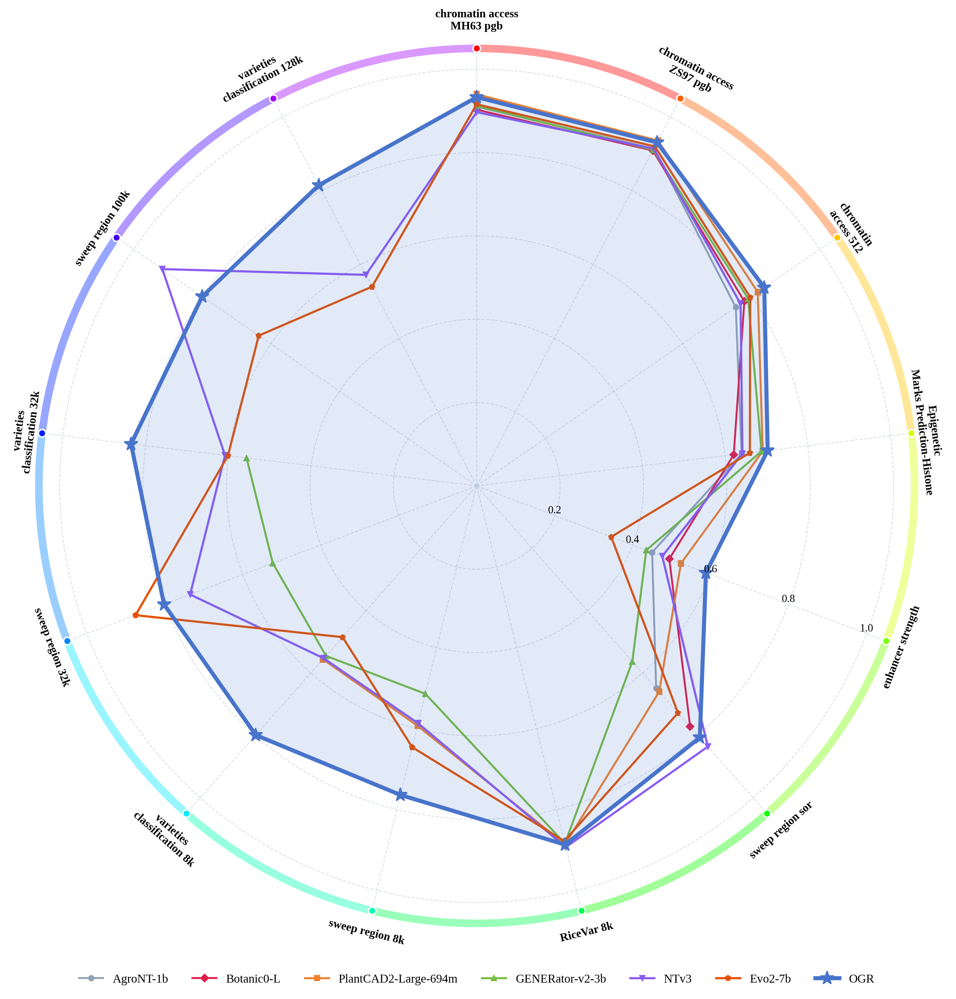

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- 统一字体：Times New Roman ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学符号与 Times 风格匹配
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 数据准备
# ---------------------------------------------------------
df = pd.read_csv('evaluation2.csv')
models = [c for c in df.columns if c != 'Evaluation Dataset']
data = df.set_index('Evaluation Dataset').copy()

for col in models:
    data[col] = pd.to_numeric(data[col].replace('/', np.nan), errors='coerce')

ordered_datasets = [
    'chromatin_access_MH63_pgb',
    'chromatin_access_ZS97_pgb',
    'chromatin_access_512',
    'Epigenetic_Marks_Prediction-Histone',
    'enhancer_strength',
    'sweep_region_sor',
    'RiceVar_8k',
    'sweep_region_8k',
    'varieties_classification_8k',
    'sweep_region_32k',
    'varieties_classification_32k',
    'sweep_region_100k',
    'varieties_classification_128k'
]

data_reordered = data.loc[ordered_datasets]
# data_reordered = data.copy()

# 💡 动态设置：根据数据行数自动生成数据集顺序（有多少行就画多少条雷达轴）
ordered_datasets = data_reordered.index.tolist()

N = len(ordered_datasets)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles_closed = angles + angles[:1]

ring_r = 1.05  # 色环半径

# ---------------------------------------------------------
# 💡 优化 1：生成顶刊级别的柔和连续渐变色系 (HSL / Spectral)
# ---------------------------------------------------------
# 使用 HSV 空间平滑映射 N 个数据点的渐变色，保证颜色环连贯自然
cmap = plt.cm.get_cmap('hsv')
colors = [cmap(i / float(N) * 0.85) for i in range(N)]  # 取 0.85 避免首尾红红重叠

# ---------------------------------------------------------
# 2. 画布与基础设置（白底）
# ---------------------------------------------------------
fig = plt.figure(figsize=(11, 11), dpi=300)
fig.patch.set_facecolor('white')          # 画布白底
ax = fig.add_subplot(111, polar=True)
ax.set_facecolor('white')                 # 坐标区白底

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([])
ax.set_ylim(0, ring_r+0.01)

# 网格样式（浅灰网格，白底上清晰且不喧宾夺主）
ax.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.7)
ax.spines['polar'].set_visible(False)

# ---------------------------------------------------------
# 💡 优化 2：绘制外围圆弧与高质感白边圆点
# ---------------------------------------------------------

for i in range(N):
    a1 = angles[i]
    a2 = angles[(i + 1) % N]
    if a2 < a1: 
        a2 += 2 * np.pi
    
    # 画半透明渐变圆弧
    arc_theta = np.linspace(a1, a2, 40)
    arc_r = np.full_like(arc_theta, ring_r)
    ax.plot(arc_theta, arc_r, color=colors[i], linewidth=6, alpha=0.4, solid_capstyle='round')
    
    # 绘制高质感节点小圆点（带有白色描边，层次感极强）
    ax.scatter(angles[i], ring_r, color=colors[i], s=35, edgecolor='white', linewidth=1.2, zorder=25)

# ---------------------------------------------------------
# 3. 折线数据绘制
# ---------------------------------------------------------
# 绿色 #75bd42
# 蓝色 #4874CB
# 橙色 #ef822f
model_styles = {
    'AgroNT-1b': {'color': '#94A3B8', 'marker': 'o', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'PlantCAD2-Large-694m': {'color': '#ef822f', 'marker': 's', 'lw': 1.6, 'alpha': 0.7, 'zorder': 4},
    'GENERator-v2-3b': {'color': '#75bd42', 'marker': '^', 'lw': 1.6, 'alpha': 0.7, 'zorder': 5},
    'Botanic0-L': {'color': '#E11D48', 'marker': 'D', 'lw': 1.5, 'alpha': 0.6, 'zorder': 3},
    'NTv3': {'color': '#8B5CF6', 'marker': 'v', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'Evo2-7b': {'color': '#E65100', 'marker': 'p', 'lw': 1.7, 'alpha': 0.75, 'zorder': 6},
    'OGR': {'color': "#4874CB", 'marker': '*', 'lw': 3.2, 'ms': 11, 'alpha': 1.0, 'zorder': 10}
}

for model in models:
    if model not in model_styles:
        continue
    vals = data_reordered[model].values
    style = model_styles[model]
    
    first_val, last_val = vals[0], vals[-1]
    is_closed = not np.isnan(first_val) and not np.isnan(last_val)
    vals_closed = np.append(vals, first_val if is_closed else np.nan)
    
    ax.plot(
        angles_closed, vals_closed,
        color=style['color'],
        linewidth=style['lw'],
        marker=style['marker'],
        markersize=style.get('ms', 4),
        label=model,
        zorder=style['zorder']
    )
    if model == 'OGR':
        ax.fill(angles_closed, vals_closed, color=style['color'], alpha=0.15, zorder=style['zorder']-1)

# ---------------------------------------------------------
# 4. 右下角斜向刻度值 (0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------
scale_angle = angles[4]  # 选择约 4:30 方向的放射轴
for tick in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.text(
        scale_angle, tick, f"{tick:.1f}",
        fontsize=8.5,
        fontweight='medium',
        color='black',   # 黑字
        ha='center',
        va='bottom',
        zorder=30
    )

# ---------------------------------------------------------
# 💡 优化 3：智能分行 + 经典切线旋转标签（解决字间距错乱问题）
# ---------------------------------------------------------
r_text = ring_r + 0.04  # 标签半径

for i, dataset in enumerate(ordered_datasets):
    angle_rad = angles[i]
    angle_deg = np.degrees(angle_rad)
    
    # 计算屏幕上的切线旋转角度（确保文字方向朝上易读）
    screen_angle = (90 - angle_deg) % 360
    rot = (screen_angle - 90 + 180) % 360 - 180
    if rot > 90 or rot < -90:
        rot += 180
        
    # 处理名字与长文本自动换行
    words = dataset.replace('_', ' ').split(' ')
    mid = len(words) // 2
    clean_name = f"{' '.join(words[:mid])}\n{' '.join(words[mid:])}" if len(' '.join(words)) > 18 and mid > 0 else ' '.join(words)
    
    # 动态确定垂直对齐方式
    va = 'bottom' if 45 <= screen_angle <= 135 else ('top' if 225 <= screen_angle <= 315 else 'center')
    
    ax.text(
            angle_rad, r_text, clean_name,
            rotation=rot,
            rotation_mode='anchor',
            ha='center',
            va=va,
            fontsize=9,
            fontweight='bold',
            color='black',   # 黑字
            multialignment='center',
            zorder=20
        )

# ---------------------------------------------------------
# 5. 图例排版（白底黑字）
# ---------------------------------------------------------
leg = plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=7,
    frameon=False,
    fontsize=9.5
)
for text in leg.get_texts():
    text.set_color('black')   # 图例文字改黑

plt.tight_layout()
plt.savefig('perfect_radar_white.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()